# Exploratory Data Analysis and Weather Prediction using Python
## Dataset: Daily Delhi Climate Dataset

# Task 1 = Data Understanding

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [101]:
train_df = pd.read_csv("DailyDelhiClimateTrain.csv")
test_df = pd.read_csv("DailyDelhiClimateTest.csv")

print(train_df.head())
print(train_df.tail())

         date   meantemp   humidity  wind_speed  meanpressure
0  01-01-2013  10.000000  84.500000    0.000000   1015.666667
1  02-01-2013   7.400000  92.000000    2.980000   1017.800000
2  03-01-2013   7.166667  87.000000    4.633333   1018.666667
3  04-01-2013   8.666667  71.333333    1.233333   1017.166667
4  05-01-2013   6.000000  86.833333    3.700000   1016.500000
            date   meantemp    humidity  wind_speed  meanpressure
1457  28-12-2016  17.217391   68.043478    3.547826   1015.565217
1458  29-12-2016  15.238095   87.857143    6.000000   1016.904762
1459  30-12-2016  14.095238   89.666667    6.266667   1017.904762
1460  31-12-2016  15.052632   87.000000    7.325000   1016.100000
1461  01-01-2017  10.000000  100.000000    0.000000   1016.000000


In [102]:
print(train_df.shape)

(1462, 5)


In [103]:
print(train_df.columns)

Index(['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure'], dtype='str')


In [104]:
print(train_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   str    
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), str(1)
memory usage: 57.2 KB
None


In [105]:
print(train_df.describe())

          meantemp     humidity   wind_speed  meanpressure
count  1462.000000  1462.000000  1462.000000   1462.000000
mean     25.495521    60.771702     6.802209   1011.104548
std       7.348103    16.769652     4.561602    180.231668
min       6.000000    13.428571     0.000000     -3.041667
25%      18.857143    50.375000     3.475000   1001.580357
50%      27.714286    62.625000     6.221667   1008.563492
75%      31.305804    72.218750     9.238235   1014.944901
max      38.714286   100.000000    42.220000   7679.333333


# Task 2 = Exploratory Data Analysis

In [106]:
# covert date column into datetime

train_df['date'] = pd.to_datetime(train_df['date'] , dayfirst=True)
test_df['date'] = pd.to_datetime(test_df['date'] , dayfirst=True)

In [107]:
# set date as index

train_df.set_index('date' , inplace=True)
test_df.set_index('date', inplace=True)

In [108]:
print(train_df.dtypes)

meantemp        float64
humidity        float64
wind_speed      float64
meanpressure    float64
dtype: object


# 2.1 Univariate Analysis

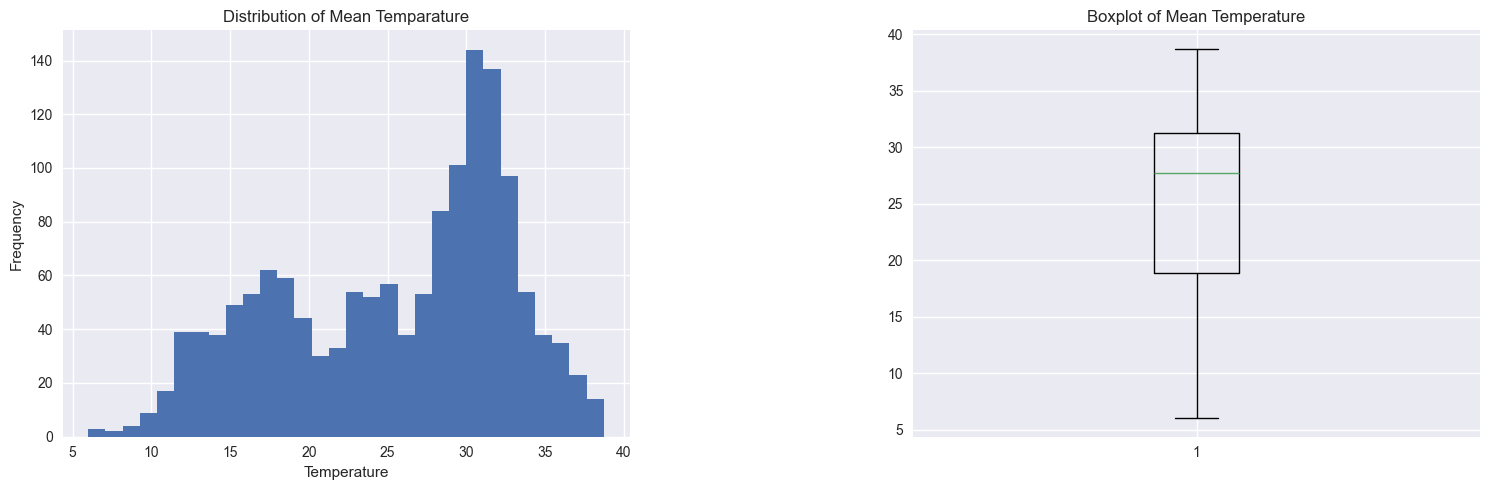

In [109]:
plt.figure(figsize=(15,5))

# Histogram of Mean Temperature
plt.subplot(1,2,1)
plt.hist(train_df['meantemp'], bins=30)
plt.title("Distribution of Mean Temparature")
plt.xlabel("Temperature")
plt.ylabel("Frequency")

# Boxplot of Mean Temperature
plt.subplot(1,2,2)
plt.boxplot(train_df['meantemp'])
plt.title("Boxplot of Mean Temperature")

plt.tight_layout()
plt.subplots_adjust(wspace=0.5)
plt.show()

# Observation:
# The histogram shows that most of the mean temperature values lie between 25°C and 35°C, indicating that Delhi generally experiences warm climatic conditions. 
# The boxplot shows the median temperature around 27–28°C and indicates a few lower temperature values, suggesting some seasonal variation in the dataset.

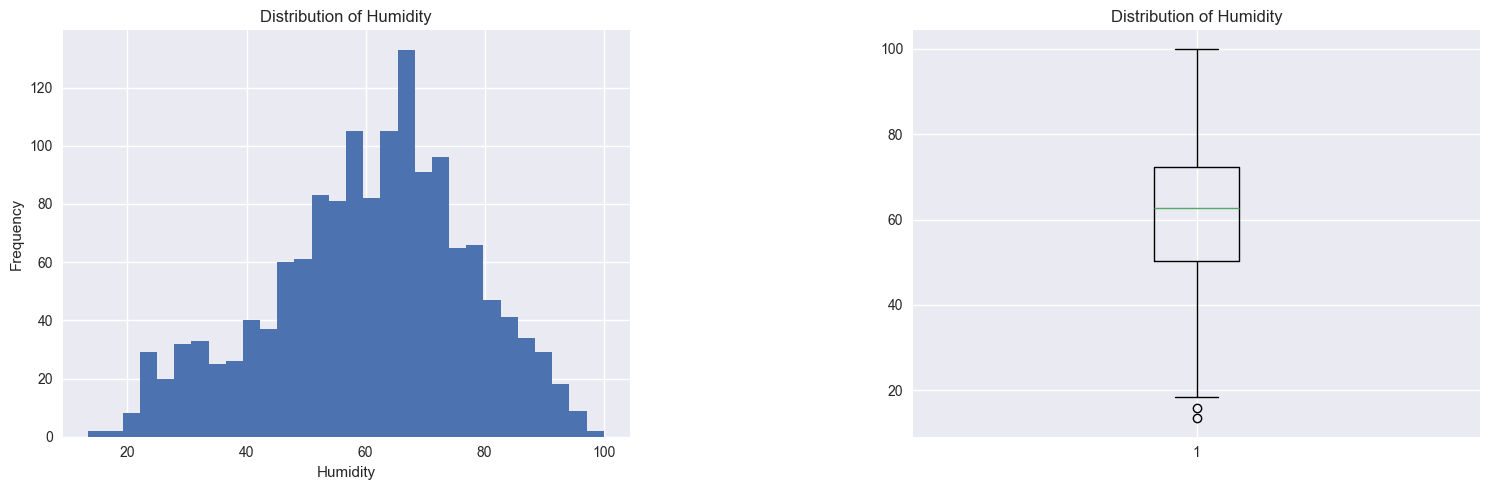

In [110]:
plt.figure(figsize=(15,5))

# Histogram of Humidity
plt.subplot(1,2,1)
plt.hist(train_df['humidity'], bins=30)
plt.title("Distribution of Humidity")
plt.xlabel("Humidity")
plt.ylabel("Frequency")

# Boxplot of Humidity
plt.subplot(1,2,2)
plt.boxplot(train_df['humidity'])
plt.title("Distribution of Humidity")

plt.tight_layout()
plt.subplots_adjust(wspace=0.5)
plt.show()

# Observation:
# The histogram shows that most humidity values lie between 50% and 80%, indicating that Delhi generally experiences moderate to high humidity levels. 
# The boxplot shows a median humidity around 60–65%, with a few lower outliers, suggesting that occasionally very dry conditions occur but are less common.

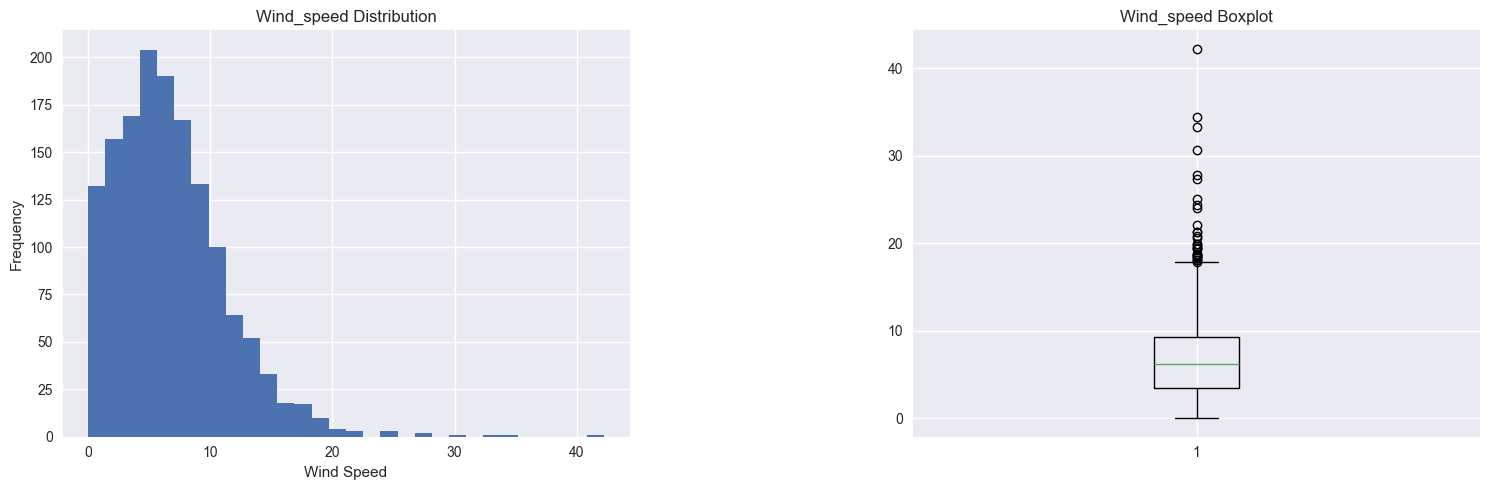

In [111]:
plt.figure(figsize=(15,5))

# Histogram of wind_speed
plt.subplot(1,2,1)
plt.hist(train_df['wind_speed'], bins=30)
plt.title("Wind_speed Distribution")
plt.xlabel("Wind Speed")
plt.ylabel("Frequency")

#Boxplot of wind_speed
plt.subplot(1,2,2)
plt.boxplot(train_df['wind_speed'])
plt.title("Wind_speed Boxplot")


plt.tight_layout()
plt.subplots_adjust(wspace=0.5)
plt.show()

# Observation:
# The histogram shows that most wind speed values are concentrated between 0 and 10, indicating generally low to moderate wind conditions in Delhi. 
# The boxplot shows several outliers at higher wind speeds, suggesting that occasionally strong winds occur but they are relatively rare.

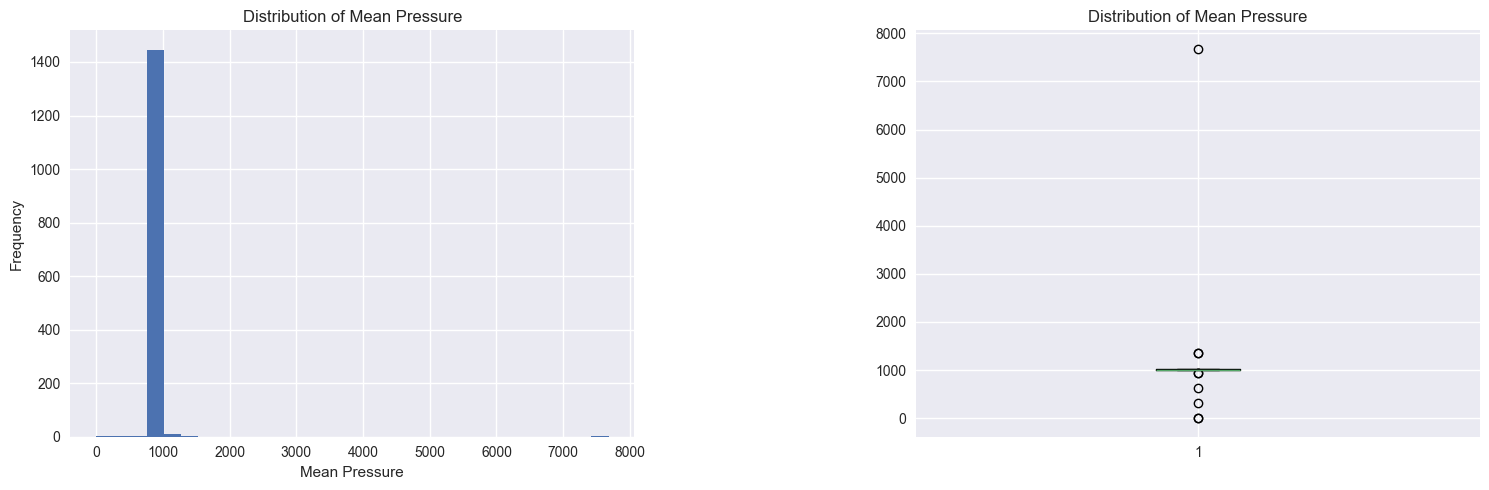

In [112]:
plt.figure(figsize=(15,5))

#Histogram of Mean Pressure
plt.subplot(1,2,1)
plt.hist(train_df['meanpressure'], bins=30)
plt.title("Distribution of Mean Pressure")
plt.xlabel("Mean Pressure")
plt.ylabel("Frequency")

#Boxplot of Mean Pressure
plt.subplot(1,2,2)
plt.boxplot(train_df['meanpressure'])
plt.title("Distribution of Mean Pressure")

plt.tight_layout()
plt.subplots_adjust(wspace=0.5)
plt.show()

# Observation:
# The histogram shows that most mean pressure values are concentrated around the normal atmospheric pressure range near 1000. 
# The boxplot indicates several extreme outliers, including one very high value, suggesting possible anomalies or unusual pressure readings in the dataset.

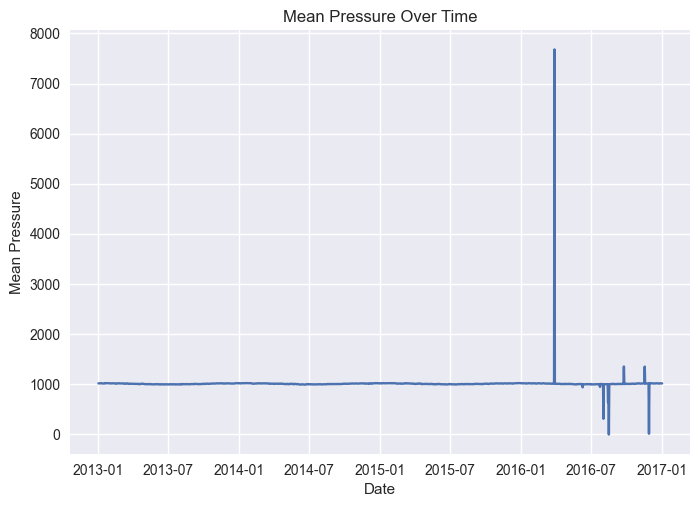

In [113]:
#Pressure overtime

plt.figure()
plt.plot(train_df.index, train_df['meanpressure'])
plt.title("Mean Pressure Over Time")
plt.xlabel("Date")
plt.ylabel("Mean Pressure")
plt.show()

# 2.2 Bivariate Analysis

In [114]:
# Correlation of all parameters
correlation = train_df.corr()
print(correlation)

              meantemp  humidity  wind_speed  meanpressure
meantemp      1.000000 -0.571951    0.306468     -0.038818
humidity     -0.571951  1.000000   -0.373972      0.001734
wind_speed    0.306468 -0.373972    1.000000     -0.020670
meanpressure -0.038818  0.001734   -0.020670      1.000000


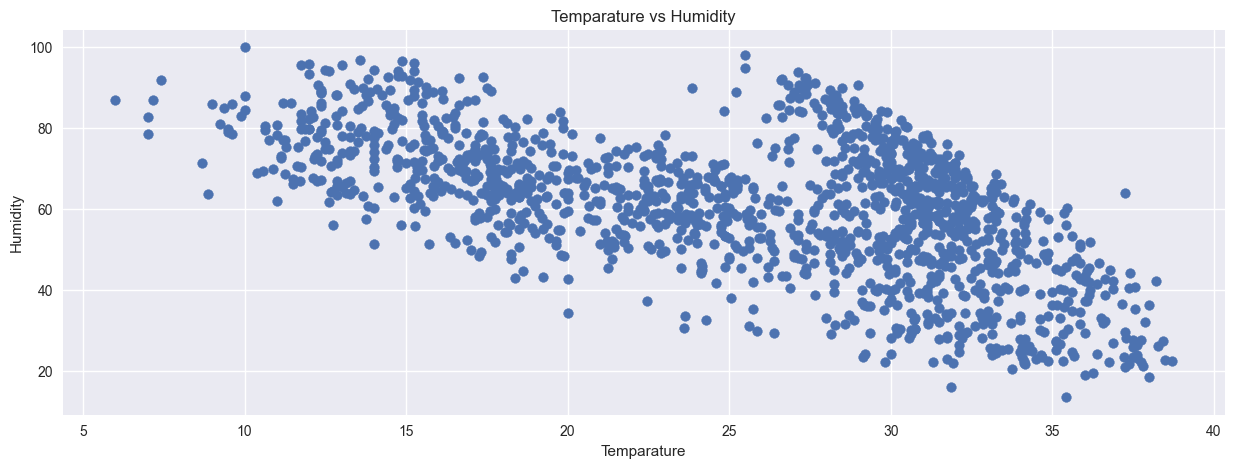

In [115]:
# Scatter plot between Temprature and Humidity

plt.figure(figsize=(15,5))

plt.scatter(train_df['meantemp'],train_df['humidity'])
plt.xlabel("Temparature")
plt.ylabel("Humidity")
plt.title("Temparature vs Humidity")

plt.show()

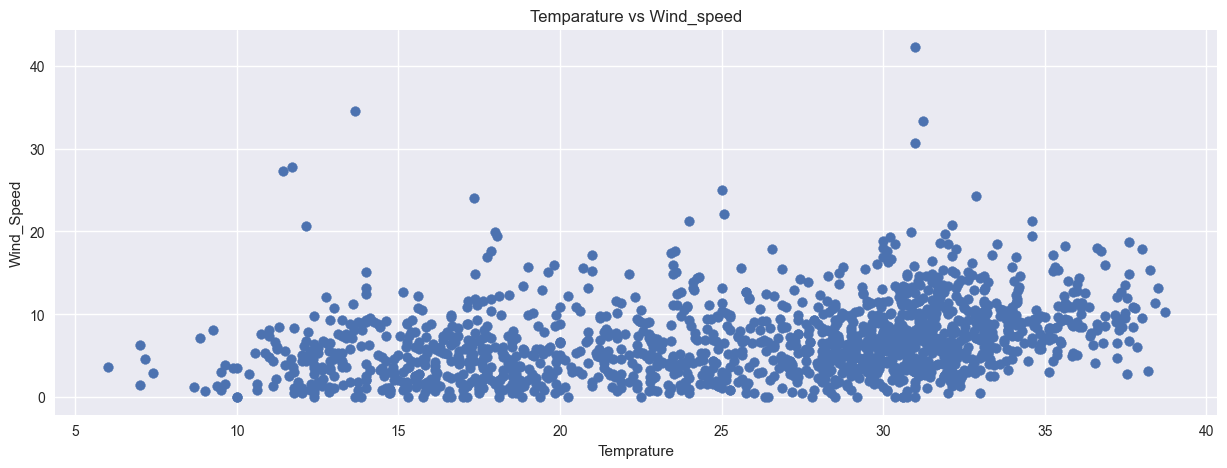

In [116]:
# Scatter plot between Temparature and Wind speed

plt.figure(figsize=(15,5))

plt.scatter(train_df['meantemp'],train_df['wind_speed'])
plt.xlabel("Temprature")
plt.ylabel("Wind_Speed")
plt.title("Temparature vs Wind_speed")

plt.show()

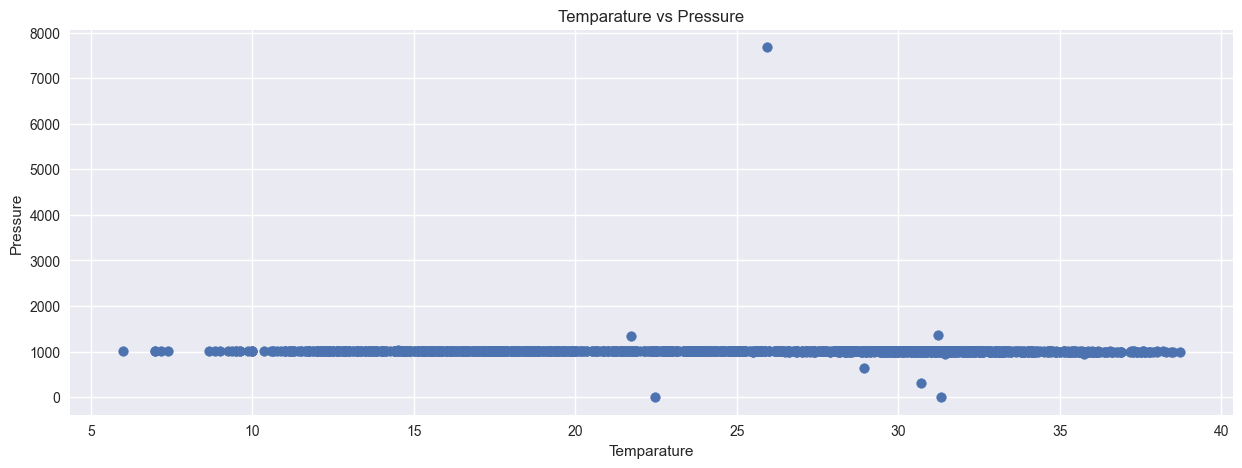

In [117]:
# Scatter plot between Temparature and Pressure

plt.figure(figsize=(15,5))

plt.scatter(train_df['meantemp'],train_df['meanpressure'])
plt.xlabel("Temparature")
plt.ylabel("Pressure")
plt.title("Temparature vs Pressure")

plt.show()

# 2.3 Multivariate analysis

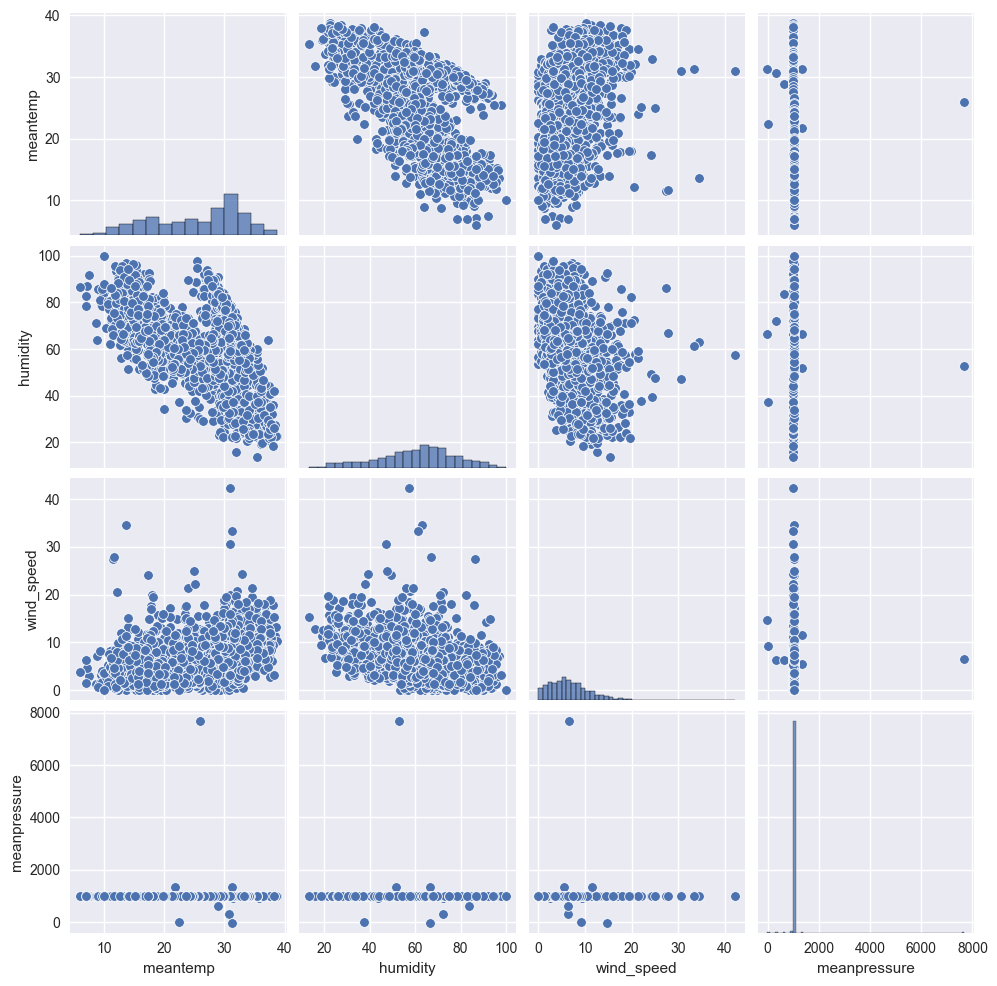

In [118]:
# pairplot of all parameters

sns.pairplot(train_df)
plt.show()

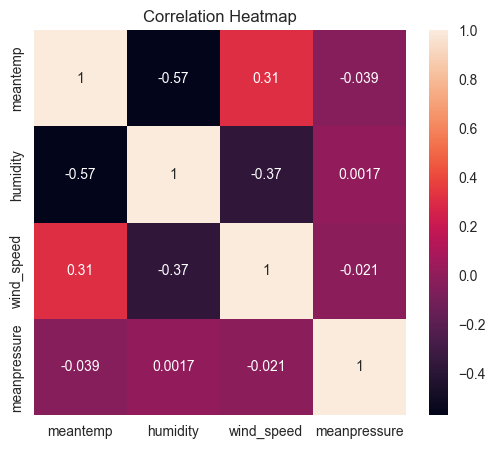

In [119]:
#Heatmap of all parameters
plt.figure(figsize=(6,5))
sns.heatmap(correlation, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Task 3 = Handling Missing Data and Outliers

In [120]:
#Checking Null Values
train_df.isnull().sum()

meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

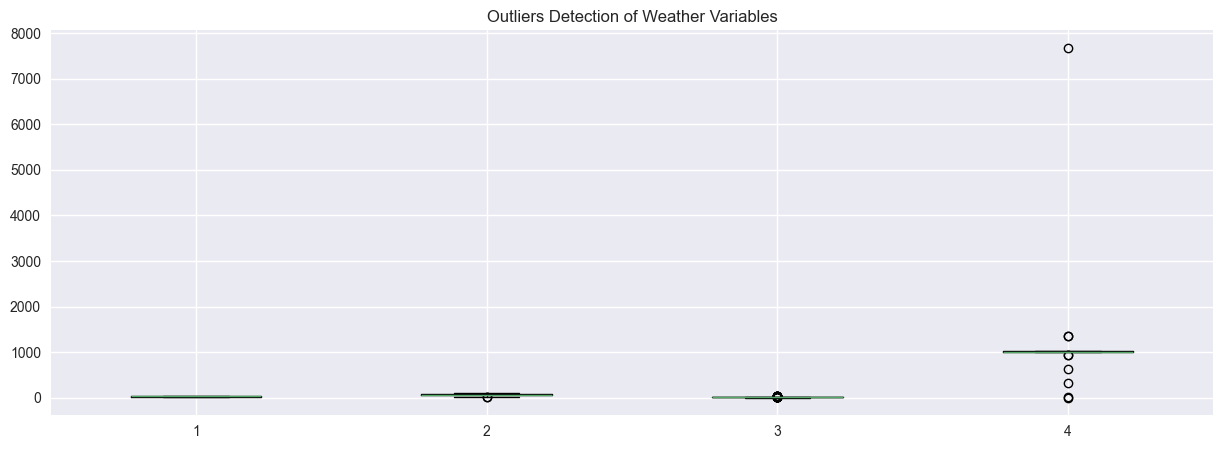

In [121]:
#Outliers 
plt.figure(figsize=(15,5))
plt.boxplot(train_df)
plt.title("Outliers Detection of Weather Variables")

plt.show()

# Task 4 = Spread of Data

# 4.1 Calculate Statistical Measure

In [122]:
# import numpy as np

#Mean , Median , Standard Deviation
temp = train_df['meantemp']

print("Mean(Numpy) : ",np.mean(temp))
print("Median(Numpy) : ",np.median(temp))
print("Standard Deviation(Numpy) : ",np.std(temp))

Mean(Numpy) :  25.495520655787278
Median(Numpy) :  27.71428571
Standard Deviation(Numpy) :  7.345589264524974


In [123]:
# Skewness and Kurtosis

print("Skewness\n",train_df.skew())
print("\nKurtosis\n",train_df.kurt())

Skewness
 meantemp        -0.446352
humidity        -0.343977
wind_speed       1.436577
meanpressure    34.435887
dtype: float64

Kurtosis
 meantemp          -0.938090
humidity          -0.310012
wind_speed         5.043260
meanpressure    1286.326728
dtype: float64


# Task 5 = Automating EDA using Python

In [124]:
#step1 : Dataset Information
print("Dataset info: \n")
train_df.info()

Dataset info: 

<class 'pandas.DataFrame'>
DatetimeIndex: 1462 entries, 2013-01-01 to 2017-01-01
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   meantemp      1462 non-null   float64
 1   humidity      1462 non-null   float64
 2   wind_speed    1462 non-null   float64
 3   meanpressure  1462 non-null   float64
dtypes: float64(4)
memory usage: 57.1 KB


In [125]:
#step2 : Statistical Summary
print("\n Statistical Summary: \n")
train_df.describe()


 Statistical Summary: 



,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


In [126]:
#step3 : Missing Values
print("\nMissing Values: \n")
print(train_df.isnull().sum())


Missing Values: 

meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64


In [127]:
#step4 : Correlation Matrix
print("\nCorrelation Matrix: \n")
print(train_df.corr())


Correlation Matrix: 

              meantemp  humidity  wind_speed  meanpressure
meantemp      1.000000 -0.571951    0.306468     -0.038818
humidity     -0.571951  1.000000   -0.373972      0.001734
wind_speed    0.306468 -0.373972    1.000000     -0.020670
meanpressure -0.038818  0.001734   -0.020670      1.000000


In [128]:
#step5 : Create Reusable EDA Function

def automated_eda(df):

    print("====DATASET INFO====")
    print(df.info())

    print("====STATISTICAL SUMMARY====")
    print(df.describe())

    print("====MISSING VALUES====")
    print(df.isnull().sum())

    print("====CORRELATION MATRIX====")
    print(df.corr())

In [129]:
#step6 : Run the Function

automated_eda(train_df)

====DATASET INFO====
<class 'pandas.DataFrame'>
DatetimeIndex: 1462 entries, 2013-01-01 to 2017-01-01
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   meantemp      1462 non-null   float64
 1   humidity      1462 non-null   float64
 2   wind_speed    1462 non-null   float64
 3   meanpressure  1462 non-null   float64
dtypes: float64(4)
memory usage: 57.1 KB
None
====STATISTICAL SUMMARY====
          meantemp     humidity   wind_speed  meanpressure
count  1462.000000  1462.000000  1462.000000   1462.000000
mean     25.495521    60.771702     6.802209   1011.104548
std       7.348103    16.769652     4.561602    180.231668
min       6.000000    13.428571     0.000000     -3.041667
25%      18.857143    50.375000     3.475000   1001.580357
50%      27.714286    62.625000     6.221667   1008.563492
75%      31.305804    72.218750     9.238235   1014.944901
max      38.714286   100.000000    42.220000   7679.333333
===

# Task 6 : Regression Analysis

In [130]:
#Identifying  Independent and Dependent Variable

#Independent variable := Temprature
#Dependent variable := Humidity

In [131]:
! pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [132]:
#Simple Linear Regression (Predicting Temprature using Humidity)
from sklearn.linear_model import LinearRegression

# Independent variable
X = train_df[['humidity']]

# Dependent variable
y = train_df['meantemp']

model = LinearRegression()

model.fit(X,y)

print("Intercept:",model.intercept_)
print("Slope:",model.coef_)

Intercept: 40.725915625281104
Slope: [-0.25061656]


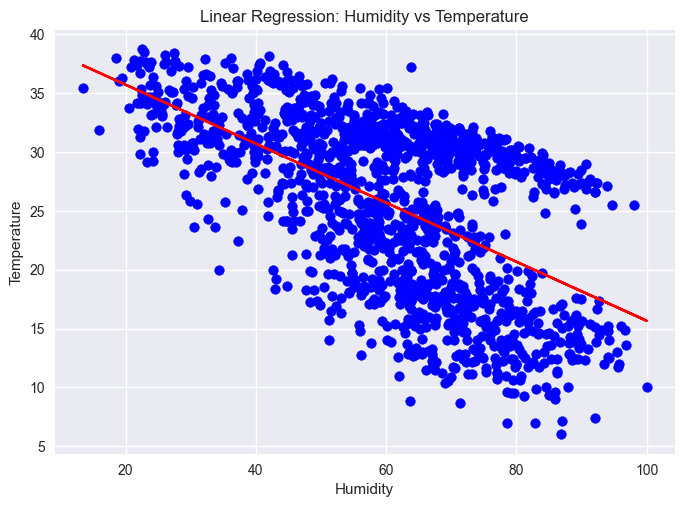

In [133]:
#Regression Line Graph
import matplotlib.pyplot as plt

plt.scatter(X, y, color='blue')
plt.plot(X, model.predict(X), color='red')

plt.xlabel("Humidity")
plt.ylabel("Temperature")
plt.title("Linear Regression: Humidity vs Temperature")

plt.show()

In [134]:
# Covariance
print("Covariance Matrix")
print(train_df[['humidity','meantemp']].cov())

# Correlation
print("\nCorrelation Matrix")
print(train_df[['humidity','meantemp']].corr())

Covariance Matrix
            humidity   meantemp
humidity  281.221237 -70.478700
meantemp  -70.478700  53.994614

Correlation Matrix
          humidity  meantemp
humidity  1.000000 -0.571951
meantemp -0.571951  1.000000


# Task 7 = Supervised Learning

In [135]:
#7.1 Split Dataset into Training and Testing Data
from sklearn.model_selection import train_test_split

# Independent variable
X = train_df[['humidity']]

# Dependent variable
y = train_df['meantemp']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (1169, 1)
Testing data size: (293, 1)


In [136]:
#1.Build Simple Linear Regression Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict values
y_pred = model.predict(X_test)

print("Model trained successfully")

Model trained successfully


In [137]:
#Validate Model Performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 5.272164887977105
MSE: 36.9986946474648
R2 Score: 0.3117730664670546


In [138]:
#2.Multiple Linear Regression Model
#Predict temperature using: humidity, wind_speed, meanpressure
X_multi = train_df[['humidity','wind_speed','meanpressure']]
y_multi = train_df['meantemp']

X_train, X_test, y_train, y_test = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 39.33621193585822
Coefficients: [-0.22980123  0.20243611 -0.00118761]


In [139]:
#Test Final Model
y_pred = model.predict(X_test)

print("Predicted Temperature:", y_pred[:5])
print("Actual Temperature:", y_test[:5])

Predicted Temperature: [32.77204602 23.33753171 26.09260621 35.59737618 22.63007728]
Actual Temperature: date
2015-06-12    35.875
2016-01-12    18.000
2014-02-18    15.250
2014-06-07    38.500
2015-11-03    24.000
Name: meantemp, dtype: float64


In [140]:
#3.Logistic Regression Model
    #Classification between cold and hot temperature
    #temperature > 25 = Hot
    #temperature <= 25 = Cold

#Convert Temperature to Category
train_df['temp_category'] = (train_df['meantemp'] > 25).astype(int)

#Logistic Regression Model
from sklearn.linear_model import LogisticRegression

X = train_df[['humidity','wind_speed','meanpressure']]
y = train_df['temp_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(predictions[:10])


[1 0 1 1 0 0 0 1 1 1]


In [141]:
#Model Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.6484641638225256


# Task 8 : Compare Training and Testing Errors

In [142]:
from sklearn.metrics import mean_squared_error

# Training prediction
train_pred = model.predict(X_train)

# Testing prediction
test_pred = model.predict(X_test)

# Errors
train_error = mean_squared_error(y_train, train_pred)
test_error = mean_squared_error(y_test, test_pred)

print("Training Error:", train_error)
print("Testing Error:", test_error)

Training Error: 0.33105218135158254
Testing Error: 0.3515358361774744


# Task 9 : Model Evaluation

In [143]:
#Evalute the temperature prediction model works
#Task 11: Model Evaluation 
#1.Mean Squared Error (MSE)
#2.Mean Squared Error (MSE)
#3.R² Score

In [144]:
#Predict Temperature on Test Data
y_pred = model.predict(X_test)

In [145]:
#Calculate Evalution Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Squared Error: 0.3515358361774744
Mean Absolute Error: 0.3515358361774744
R2 Score: -0.41340389659048316


# Task 10 : Data Visualization using 3D plot

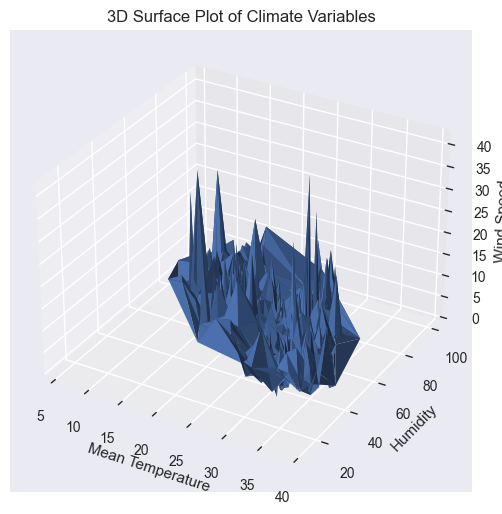

In [146]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

x = train_df['meantemp']
y = train_df['humidity']
z = train_df['wind_speed']

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_trisurf(x, y, z)

ax.set_xlabel('Mean Temperature')
ax.set_ylabel('Humidity')
ax.set_zlabel('Wind Speed')

plt.title("3D Surface Plot of Climate Variables")
plt.show()